Step 1. Importing required **libraries**

In [1]:
import pandas as pd # for uploading the data
import numpy as np # for calculations
import re # for data cleaning
import nltk # for preprocessing
import matplotlib.pyplot as plt # for
from nltk.corpus import stopwords # to remove the unnecesary words
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud # To visualize the word

In [10]:
# Download required NLTK files
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon') # (valence Aware Dictinonary and sentiment Reasoner) rule based analysis
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

Step 2. Loading **data**

In [11]:
data = {
    "Review": [
        "The product quality is excellent and delivery was very fast.",
        "Very bad packaging and the item was damaged.",
        "Customer service was helpful and responsive.",
        "The delivery was delayed and support team did not respond.",
        "Amazing product. Worth the money.",
        "Poor quality product and terrible experience.",
        "Fast shipping and good packaging.",
        "The product stopped working after two days.",
        "Excellent service and great quality.",
        "Late delivery and bad customer support."
    ]
}

# Create DataFrame
df = pd.DataFrame(data)
# create dataframe
df=pd.DataFrame(data)

#Display first few rows
print("Coustomer Reviews Dataset")
print(df.head())

Coustomer Reviews Dataset
                                              Review
0  The product quality is excellent and delivery ...
1       Very bad packaging and the item was damaged.
2       Customer service was helpful and responsive.
3  The delivery was delayed and support team did ...
4                  Amazing product. Worth the money.


In [13]:
stop_words=set(stopwords.words('english'))

def clean_text(text):

  #Convert to lowercase
  text=text.lower()

  #Remove special characters and numbers
  text=re.sub('[^a-zA-Z]'," ",text)

  #Tokenization
  words=word_tokenize(text)

  #Remove stopwords
  words=[word for word in words if word not in stop_words]
  print('Without stopwords',words)

  #join words align
  cleaned_text=" ".join(words)

  return cleaned_text

#Apply cleaning function
df["Cleaned_Review"]=df["Review"].apply(clean_text)

print("\nCleaned Review")
print(df[['Review','Cleaned_Review']])

Without stopwords ['product', 'quality', 'excellent', 'delivery', 'fast']
Without stopwords ['bad', 'packaging', 'item', 'damaged']
Without stopwords ['customer', 'service', 'helpful', 'responsive']
Without stopwords ['delivery', 'delayed', 'support', 'team', 'respond']
Without stopwords ['amazing', 'product', 'worth', 'money']
Without stopwords ['poor', 'quality', 'product', 'terrible', 'experience']
Without stopwords ['fast', 'shipping', 'good', 'packaging']
Without stopwords ['product', 'stopped', 'working', 'two', 'days']
Without stopwords ['excellent', 'service', 'great', 'quality']
Without stopwords ['late', 'delivery', 'bad', 'customer', 'support']

Cleaned Review
                                              Review  \
0  The product quality is excellent and delivery ...   
1       Very bad packaging and the item was damaged.   
2       Customer service was helpful and responsive.   
3  The delivery was delayed and support team did ...   
4                  Amazing product. Wort

Step 4. Sentiment Analysis

In [33]:
sia=SentimentIntensityAnalyzer() # depends upon the word it will give u value
def analyze_sentiment(review):
  score = sia.polarity_scores(review)   #
  compound=score['compound']   # combined values
  if compound >=0.05:
    return "Positive"
  elif compound <=-0.05:
    return "Negative"
  else:
    return "Neutral"

  #Apply sentiment Analysis
  df['Sentiment']=df['Cleaned_Review'].apply(analyze_sentiment)

  #Display sentiment analysis
  print("\nSentiment Analysis Result")
  print(df[['Review','Sentiment']])

Step 5. Find common keywords

In [18]:
all_words="".join(df['Cleaned_Review'])  #converting to string

word_list=all_words.split() # splits the word individual
word_freq=Counter(word_list)  # count word frequency

print("\nTop 10 Common Keywords")
print(word_freq.most_common(10))


Top 10 Common Keywords
[('product', 3), ('quality', 2), ('delivery', 2), ('service', 2), ('support', 2), ('excellent', 1), ('fastbad', 1), ('packaging', 1), ('item', 1), ('damagedcustomer', 1)]


Step 6. Identify common complaints

In [32]:
df['Sentiment'] = df['Cleaned_Review'].apply(analyze_sentiment)
negative_reviews = df[df['Sentiment'] =='Negative']   # Row filter
negative_words =' '.join(negative_reviews['Cleaned_Review'])

negative_word_list=negative_words.split()
complaint_freq=Counter(negative_word_list)

print("\nMost Common Complaint Keywords")
print(complaint_freq.most_common(10))


Most Common Complaint Keywords
[('bad', 2), ('product', 2), ('packaging', 1), ('item', 1), ('damaged', 1), ('poor', 1), ('quality', 1), ('terrible', 1), ('experience', 1), ('stopped', 1)]


Step 7. Visualization - Sentiment Count

In [35]:
sentiment_counts=df['Sentiment'].value_counts()  # it will category count
sentiment_counts

,count
Sentiment,
Positive,6
Negative,4


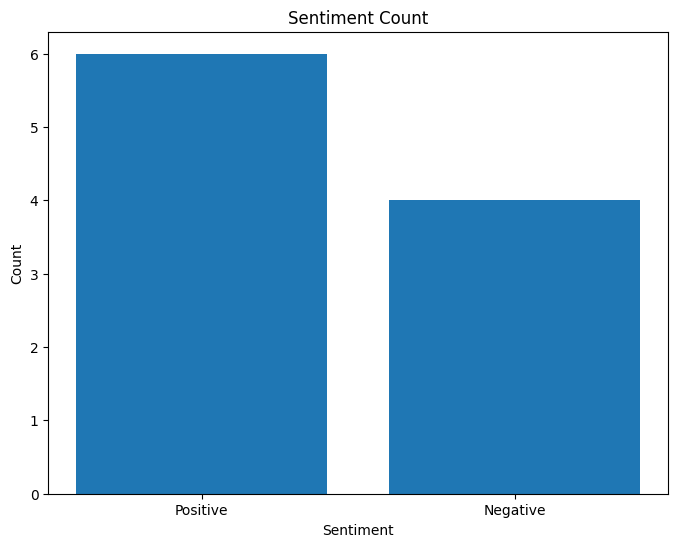

In [36]:
sentiment_counts=df['Sentiment'].value_counts()  # it will category count

plt.figure(figsize=(8,6))
plt.bar(sentiment_counts.index,sentiment_counts.values)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Sentiment Count')
plt.show()

Step 8. Generate word cloud

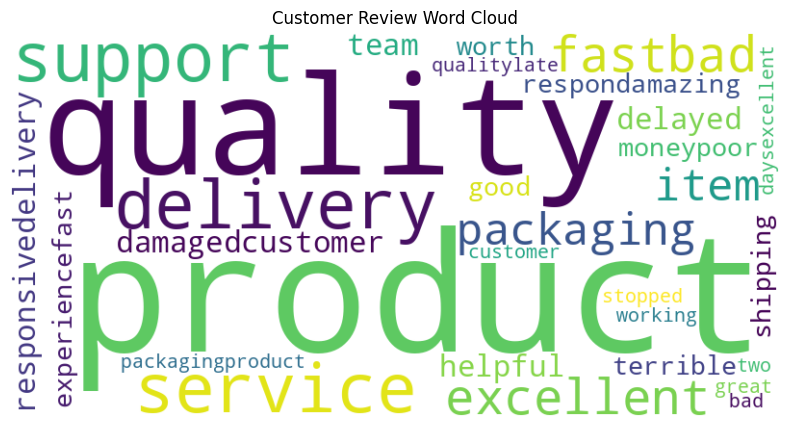

In [39]:
wordcloud=WordCloud(
    width=800,
    height=400,
    background_color='white'
    ).generate(all_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title('Customer Review Word Cloud')
plt.show()

In [41]:
print("\nBusiness Insights")
print("-----------------------------")

positive_count=len(df[df['Sentiment']=='Positive'])
negative_count=len(df[df['Sentiment']=='Negative'])

print("Total positive Reviews : ",positive_count)
print("Total Negative Reviews : ",negative_count)

print("\nCommon Positive Areas :")
print("\n- Positive quality")
print("\n- Fast delivery")
print("\n- Good customer service")

print("\n Common Customer Complaints :")
print("\n- Delyed delivery")
print("\n- Damaged products")
print("\n- Poor support responds")
print("\n- Product malfunction issues")

print("\nRecommendation:")
print("The company should improve delivery management,")
print("strengthen packing quality,and enhance customer support response time.")


Business Insights
-----------------------------
Total positive Reviews :  6
Total Negative Reviews :  4

Common Positive Areas :

- Positive quality

- Fast delivery

- Good customer service

 Common Customer Complaints :

- Delyed delivery

- Damaged products

- Poor support responds

- Product malfunction issues

Recommendation:
The company should improve delivery management,
strengthen packing quality,and enhance customer support response time.
